In [ ]:
!wget -O "UCI HAR Dataset.zip" "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
!rm -rf "UCI HAR Dataset"
!unzip -q "UCI HAR Dataset.zip"

--2026-03-10 09:44:49--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [ <=>                ]  58.18M  8.04MB/s    in 9.1s    

2026-03-10 09:45:00 (6.37 MB/s) - ‘UCI HAR Dataset.zip’ saved [61005872]



In [12]:
!ls "UCI HAR Dataset/train"
!ls "UCI HAR Dataset/test"

'Inertial Signals'   subject_train.txt	 X_train.txt   y_train.txt
'Inertial Signals'   subject_test.txt   X_test.txt   y_test.txt


In [13]:
import os
import copy
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import defaultdict

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.stats import friedmanchisquare, wilcoxon

In [14]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_seed(42)

In [15]:
def load_har_dataset(base_path="UCI HAR Dataset"):
    base = Path(base_path)

    X_train = np.loadtxt(base / "train" / "X_train.txt")
    y_train = np.loadtxt(base / "train" / "y_train.txt").astype(int) - 1
    subject_train = np.loadtxt(base / "train" / "subject_train.txt").astype(int)

    X_test = np.loadtxt(base / "test" / "X_test.txt")
    y_test = np.loadtxt(base / "test" / "y_test.txt").astype(int) - 1
    subject_test = np.loadtxt(base / "test" / "subject_test.txt").astype(int)

    return X_train, y_train, subject_train, X_test, y_test, subject_test

X_train, y_train, subject_train, X_test, y_test, subject_test = load_har_dataset("UCI HAR Dataset")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Unique train subjects:", len(np.unique(subject_train)))
print("Classes:", np.unique(y_train))

Train shape: (7352, 561)
Test shape: (2947, 561)
Unique train subjects: 21
Classes: [0 1 2 3 4 5]


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

print("Num features:", num_features)
print("Num classes:", num_classes)

Num features: 561
Num classes: 6


In [17]:
def create_subject_wise_clients(X, y, subjects):
    clients = {}
    unique_subjects = np.unique(subjects)

    for s in unique_subjects:
        idx = np.where(subjects == s)[0]
        clients[f"client_{s}"] = {
            "x": X[idx],
            "y": y[idx]
        }
    return clients

def create_iid_clients(X, y, num_clients, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(X))
    rng.shuffle(indices)

    splits = np.array_split(indices, num_clients)
    clients = {}

    for i, split in enumerate(splits):
        clients[f"client_{i+1}"] = {
            "x": X[split],
            "y": y[split]
        }
    return clients

n_clients = len(np.unique(subject_train))

clients_non_iid = create_subject_wise_clients(X_train_scaled, y_train, subject_train)
clients_iid = create_iid_clients(X_train_scaled, y_train, n_clients, seed=42)

print("Non-IID clients:", len(clients_non_iid))
print("IID clients:", len(clients_iid))

Non-IID clients: 21
IID clients: 21


In [18]:
def client_distribution_summary(clients):
    rows = []
    for cid, data in clients.items():
        labels, counts = np.unique(data["y"], return_counts=True)
        row = {"client": cid, "samples": len(data["y"])}
        for lbl, cnt in zip(labels, counts):
            row[f"class_{lbl}"] = cnt
        rows.append(row)
    return pd.DataFrame(rows).fillna(0)

df_non_iid = client_distribution_summary(clients_non_iid)
df_iid = client_distribution_summary(clients_iid)

display(df_non_iid.head())
display(df_iid.head())

,client,samples,class_0,class_1,class_2,class_3,class_4,class_5
0,client_1,347,95,53,49,47,53,50
1,client_3,341,58,59,49,52,61,62
2,client_5,302,56,47,47,44,56,52
3,client_6,325,57,51,48,55,57,57
4,client_7,308,57,51,47,48,53,52


,client,samples,class_0,class_1,class_2,class_3,class_4,class_5
0,client_1,351,58,45,53,63,64,68
1,client_2,351,56,46,52,56,68,73
2,client_3,350,68,48,43,68,69,54
3,client_4,350,69,51,42,66,64,58
4,client_5,350,57,50,48,57,73,65


In [19]:
def build_mlp(input_dim, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [20]:
def evaluate_model(model, X, y):
    probs = model.predict(X, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average="macro")

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "preds": preds
    }

def print_full_report(model, X, y, class_names=None):
    probs = model.predict(X, verbose=0)
    preds = np.argmax(probs, axis=1)

    print(classification_report(y, preds, target_names=class_names))

    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [21]:
set_seed(42)

central_model = build_mlp(num_features, num_classes)

history_central = central_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

central_metrics = evaluate_model(central_model, X_test_scaled, y_test)
print("Centralized Accuracy:", central_metrics["accuracy"])
print("Centralized Macro F1:", central_metrics["macro_f1"])

Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7369 - loss: 0.6741 - val_accuracy: 0.9135 - val_loss: 0.2223
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9432 - loss: 0.1547 - val_accuracy: 0.9379 - val_loss: 0.1798
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9597 - loss: 0.0962 - val_accuracy: 0.9365 - val_loss: 0.1845
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9617 - loss: 0.0969 - val_accuracy: 0.9270 - val_loss: 0.2470
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9704 - loss: 0.0735 - val_accuracy: 0.9223 - val_loss: 0.2514
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9649 - loss: 0.0896 - val_accuracy: 0.9250 - val_loss: 0.2861
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9694 - loss: 0.0767 - val_accuracy: 0.9372 - val_loss: 0.2453
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0582 - val_accuracy: 0

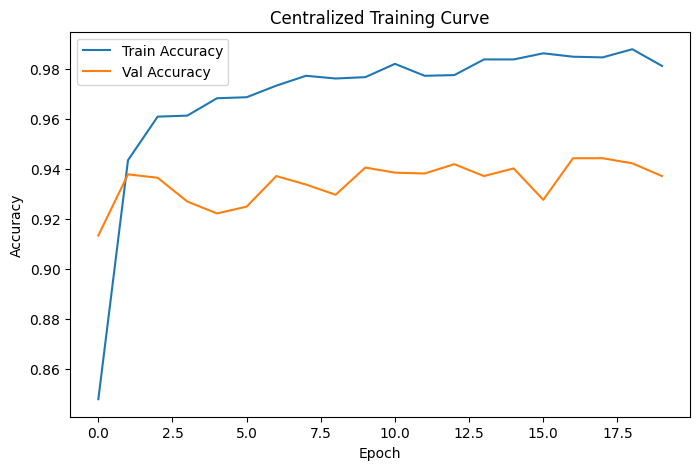

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_central.history["accuracy"], label="Train Accuracy")
plt.plot(history_central.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Centralized Training Curve")
plt.legend()
plt.show()

In [23]:
def train_local_model(global_model, x_local, y_local, local_epochs=1, batch_size=32):
    local_model = build_mlp(num_features, num_classes)
    local_model.set_weights(global_model.get_weights())

    local_model.fit(
        x_local,
        y_local,
        epochs=local_epochs,
        batch_size=batch_size,
        verbose=0
    )

    return local_model.get_weights(), len(x_local)

In [24]:
def fedavg(weight_list, sample_counts):
    new_weights = []
    total_samples = np.sum(sample_counts)

    for weights_per_layer in zip(*weight_list):
        layer_sum = np.zeros_like(weights_per_layer[0])
        for w, n in zip(weights_per_layer, sample_counts):
            layer_sum += (n / total_samples) * w
        new_weights.append(layer_sum)

    return new_weights

In [25]:
def sample_clients(clients, fraction=0.5, seed=None):
    client_ids = list(clients.keys())
    n_selected = max(1, int(len(client_ids) * fraction))

    rng = np.random.default_rng(seed)
    selected = rng.choice(client_ids, size=n_selected, replace=False)

    return selected.tolist()

In [26]:
def sample_clients(clients, fraction=0.5, seed=None):
    client_ids = list(clients.keys())
    n_selected = max(1, int(len(client_ids) * fraction))

    rng = np.random.default_rng(seed)
    selected = rng.choice(client_ids, size=n_selected, replace=False)

    return selected.tolist()

In [27]:
def federated_training(
    clients,
    X_test,
    y_test,
    rounds=50,
    client_fraction=0.5,
    local_epochs=1,
    batch_size=32,
    seed=42
):
    set_seed(seed)

    global_model = build_mlp(num_features, num_classes)

    history = {
        "round": [],
        "accuracy": [],
        "macro_f1": []
    }

    for rnd in range(1, rounds + 1):
        selected_clients = sample_clients(clients, fraction=client_fraction, seed=seed + rnd)

        local_weights = []
        local_sizes = []

        for cid in selected_clients:
            x_local = clients[cid]["x"]
            y_local = clients[cid]["y"]

            w, n = train_local_model(
                global_model,
                x_local,
                y_local,
                local_epochs=local_epochs,
                batch_size=batch_size
            )

            local_weights.append(w)
            local_sizes.append(n)

        new_global_weights = fedavg(local_weights, local_sizes)
        global_model.set_weights(new_global_weights)

        metrics = evaluate_model(global_model, X_test, y_test)

        history["round"].append(rnd)
        history["accuracy"].append(metrics["accuracy"])
        history["macro_f1"].append(metrics["macro_f1"])

        print(
            f"Round {rnd:03d} | "
            f"Accuracy: {metrics['accuracy']:.4f} | "
            f"Macro F1: {metrics['macro_f1']:.4f}"
        )

    return global_model, pd.DataFrame(history)

In [ ]:
fed_iid_model, fed_iid_history = federated_training(
    clients=clients_iid,
    X_test=X_test_scaled,
    y_test=y_test,
    rounds=50,
    client_fraction=0.5,
    local_epochs=1,
    batch_size=32,
    seed=42
)

fed_iid_metrics = evaluate_model(fed_iid_model, X_test_scaled, y_test)
print("Federated IID Accuracy:", fed_iid_metrics["accuracy"])
print("Federated IID Macro F1:", fed_iid_metrics["macro_f1"])

Round 001 | Accuracy: 0.8045 | Macro F1: 0.7991
Round 002 | Accuracy: 0.8510 | Macro F1: 0.8420
Round 003 | Accuracy: 0.8823 | Macro F1: 0.8779
Round 004 | Accuracy: 0.8887 | Macro F1: 0.8851
Round 005 | Accuracy: 0.9050 | Macro F1: 0.9034
Round 006 | Accuracy: 0.9118 | Macro F1: 0.9102
Round 007 | Accuracy: 0.9172 | Macro F1: 0.9163
Round 008 | Accuracy: 0.9223 | Macro F1: 0.9213
Round 009 | Accuracy: 0.9152 | Macro F1: 0.9137
Round 010 | Accuracy: 0.9206 | Macro F1: 0.9188
Round 011 | Accuracy: 0.9287 | Macro F1: 0.9283
Round 012 | Accuracy: 0.9233 | Macro F1: 0.9226
Round 013 | Accuracy: 0.9315 | Macro F1: 0.9309
Round 014 | Accuracy: 0.9348 | Macro F1: 0.9342


In [ ]:
fed_non_iid_model, fed_non_iid_history = federated_training(
    clients=clients_non_iid,
    X_test=X_test_scaled,
    y_test=y_test,
    rounds=50,
    client_fraction=0.5,
    local_epochs=1,
    batch_size=32,
    seed=42
)

fed_non_iid_metrics = evaluate_model(fed_non_iid_model, X_test_scaled, y_test)
print("Federated Non-IID Accuracy:", fed_non_iid_metrics["accuracy"])
print("Federated Non-IID Macro F1:", fed_non_iid_metrics["macro_f1"])

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(fed_iid_history["round"], fed_iid_history["accuracy"], label="Federated IID")
plt.plot(fed_non_iid_history["round"], fed_non_iid_history["accuracy"], label="Federated Non-IID")
plt.xlabel("Communication Round")
plt.ylabel("Test Accuracy")
plt.title("Federated Learning Accuracy Across Rounds")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(fed_iid_history["round"], fed_iid_history["macro_f1"], label="Federated IID")
plt.plot(fed_non_iid_history["round"], fed_non_iid_history["macro_f1"], label="Federated Non-IID")
plt.xlabel("Communication Round")
plt.ylabel("Macro F1")
plt.title("Federated Learning Macro F1 Across Rounds")
plt.legend()
plt.show()

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Setup": "Centralized",
        "Accuracy": central_metrics["accuracy"],
        "Macro_F1": central_metrics["macro_f1"]
    },
    {
        "Setup": "Federated IID",
        "Accuracy": fed_iid_metrics["accuracy"],
        "Macro_F1": fed_iid_metrics["macro_f1"]
    },
    {
        "Setup": "Federated Non-IID",
        "Accuracy": fed_non_iid_metrics["accuracy"],
        "Macro_F1": fed_non_iid_metrics["macro_f1"]
    }
])

comparison_df

In [ ]:
best_setup = comparison_df.sort_values("Macro_F1", ascending=False).iloc[0]["Setup"]
print("Best Setup:", best_setup)

if best_setup == "Centralized":
    best_model = central_model
elif best_setup == "Federated IID":
    best_model = fed_iid_model
else:
    best_model = fed_non_iid_model

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

print_full_report(best_model, X_test_scaled, y_test, class_names=class_names)

In [ ]:
def estimate_model_size_mb(model):
    total_params = np.sum([np.prod(w.shape) for w in model.get_weights()])
    total_bytes = total_params * 4
    return total_bytes / (1024 ** 2)

def estimate_total_comm_cost(model, rounds, num_selected_clients):
    model_size_mb = estimate_model_size_mb(model)
    total_cost = model_size_mb * 2 * rounds * num_selected_clients
    return model_size_mb, total_cost

selected_clients_per_round = max(1, int(n_clients * 0.5))
model_size_mb, total_comm_mb = estimate_total_comm_cost(
    fed_non_iid_model,
    rounds=50,
    num_selected_clients=selected_clients_per_round
)

print("Approx model size per transmission (MB):", round(model_size_mb, 4))
print("Approx total communication cost (MB):", round(total_comm_mb, 2))

In [ ]:
def run_full_experiment(seed):
    set_seed(seed)

    central_model = build_mlp(num_features, num_classes)
    central_model.fit(
        X_train_scaled,
        y_train,
        epochs=15,
        batch_size=32,
        verbose=0
    )
    central = evaluate_model(central_model, X_test_scaled, y_test)

    fed_iid_model, _ = federated_training(
        clients=clients_iid,
        X_test=X_test_scaled,
        y_test=y_test,
        rounds=30,
        client_fraction=0.5,
        local_epochs=1,
        batch_size=32,
        seed=seed
    )
    fed_iid = evaluate_model(fed_iid_model, X_test_scaled, y_test)

    fed_non_iid_model, _ = federated_training(
        clients=clients_non_iid,
        X_test=X_test_scaled,
        y_test=y_test,
        rounds=30,
        client_fraction=0.5,
        local_epochs=1,
        batch_size=32,
        seed=seed
    )
    fed_non_iid = evaluate_model(fed_non_iid_model, X_test_scaled, y_test)

    return {
        "seed": seed,
        "central_acc": central["accuracy"],
        "central_f1": central["macro_f1"],
        "fed_iid_acc": fed_iid["accuracy"],
        "fed_iid_f1": fed_iid["macro_f1"],
        "fed_non_iid_acc": fed_non_iid["accuracy"],
        "fed_non_iid_f1": fed_non_iid["macro_f1"]
    }

seeds = [7, 13, 21, 42, 99]
all_results = []

for s in seeds:
    print(f"\nRunning seed {s}")
    res = run_full_experiment(s)
    all_results.append(res)

results_df = pd.DataFrame(all_results)
results_df

In [ ]:
summary_df = pd.DataFrame({
    "Setup": ["Centralized", "Federated IID", "Federated Non-IID"],
    "Mean Accuracy": [
        results_df["central_acc"].mean(),
        results_df["fed_iid_acc"].mean(),
        results_df["fed_non_iid_acc"].mean()
    ],
    "Std Accuracy": [
        results_df["central_acc"].std(),
        results_df["fed_iid_acc"].std(),
        results_df["fed_non_iid_acc"].std()
    ],
    "Mean Macro F1": [
        results_df["central_f1"].mean(),
        results_df["fed_iid_f1"].mean(),
        results_df["fed_non_iid_f1"].mean()
    ],
    "Std Macro F1": [
        results_df["central_f1"].std(),
        results_df["fed_iid_f1"].std(),
        results_df["fed_non_iid_f1"].std()
    ]
})

summary_df

In [ ]:
friedman_acc = friedmanchisquare(
    results_df["central_acc"],
    results_df["fed_iid_acc"],
    results_df["fed_non_iid_acc"]
)

friedman_f1 = friedmanchisquare(
    results_df["central_f1"],
    results_df["fed_iid_f1"],
    results_df["fed_non_iid_f1"]
)

print("Friedman Test on Accuracy:", friedman_acc)
print("Friedman Test on Macro F1:", friedman_f1)

print("\nPairwise Wilcoxon on Macro F1")
print("Centralized vs Fed IID:", wilcoxon(results_df["central_f1"], results_df["fed_iid_f1"]))
print("Centralized vs Fed Non-IID:", wilcoxon(results_df["central_f1"], results_df["fed_non_iid_f1"]))
print("Fed IID vs Fed Non-IID:", wilcoxon(results_df["fed_iid_f1"], results_df["fed_non_iid_f1"]))

In [ ]:
ablation_results = []

for local_ep in [1, 3, 5]:
    print(f"\nRunning local_epochs = {local_ep}")

    model_ab, hist_ab = federated_training(
        clients=clients_non_iid,
        X_test=X_test_scaled,
        y_test=y_test,
        rounds=30,
        client_fraction=0.5,
        local_epochs=local_ep,
        batch_size=32,
        seed=42
    )

    met = evaluate_model(model_ab, X_test_scaled, y_test)

    ablation_results.append({
        "local_epochs": local_ep,
        "accuracy": met["accuracy"],
        "macro_f1": met["macro_f1"]
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df

In [ ]:
print("==== Final Project Summary ====")
print(summary_df)

best_row = summary_df.sort_values("Mean Macro F1", ascending=False).iloc[0]
print("\nBest overall setup based on Mean Macro F1:")
print(best_row)